In [13]:
import pandas as pd
import os
from intervaltree import IntervalTree
TARGET = 'Vapressure_average'

In [14]:
os.makedirs(f'../output/{TARGET}',exist_ok=True)
GWASFILE='/mnt/d/幽门螺旋杆菌/Script/分析结果/GWAS/output'
FSTFILE='/mnt/d/幽门螺旋杆菌/Script/分析结果/FST/output'
TARGET_GWAS_FILE='/mnt/d/幽门螺旋杆菌/Script/分析结果/GWAS/output/' + TARGET + '/bugwas_biallelic_lmmout_allSNPs.txt'
TARGET_FST_FILE='/mnt/d/幽门螺旋杆菌/Script/分析结果/FST/output/' + TARGET + '/处理后FST.csv'
df_GWAS = pd.read_csv(TARGET_GWAS_FILE,sep='\t')
df_GWAS.rename(columns={'ps':'Location'},inplace=True)
df_Fst = pd.read_csv(TARGET_FST_FILE)
df_Fst_GWAS = df_Fst.merge(df_GWAS,on='Location',how='outer').loc[:,['Location','Fst','negLog10']].fillna(0)
df_gff = pd.read_csv('/mnt/d/幽门螺旋杆菌/Script/分析结果/FST/script/R方法/NC_000915.gff',sep='\t', header=None).loc[:,[3,4,8]]
tree = IntervalTree()
for _, row in df_gff.iterrows():
    # intervaltree 右端开区间，所以加 1
    tree.addi(row[3], row[4]+1, row)
def annotate_row(pos):
    ivs = tree[pos]
    if ivs:
        # 任取一个（若存在重叠基因，可进一步筛选）
        gff_row = list(ivs)[0].data
        return gff_row[8]  # 或者直接返回整个 row，后面再拆字段
    else:
        return None

df_Fst_GWAS['annotation'] = df_Fst_GWAS['Location'].apply(annotate_row)


In [15]:
df_Fst_GWAS

,Location,Fst,negLog10,annotation
0,0,0.0,0.0,None
1,1,0.0,0.0,None
2,2,0.0,0.0,None
3,3,0.0,0.0,None
4,4,0.0,0.0,None
...,...,...,...,...
1667862,1667862,0.0,0.0,None
1667863,1667863,0.0,0.0,None
1667864,1667864,0.0,0.0,None
1667865,1667865,0.0,0.0,None


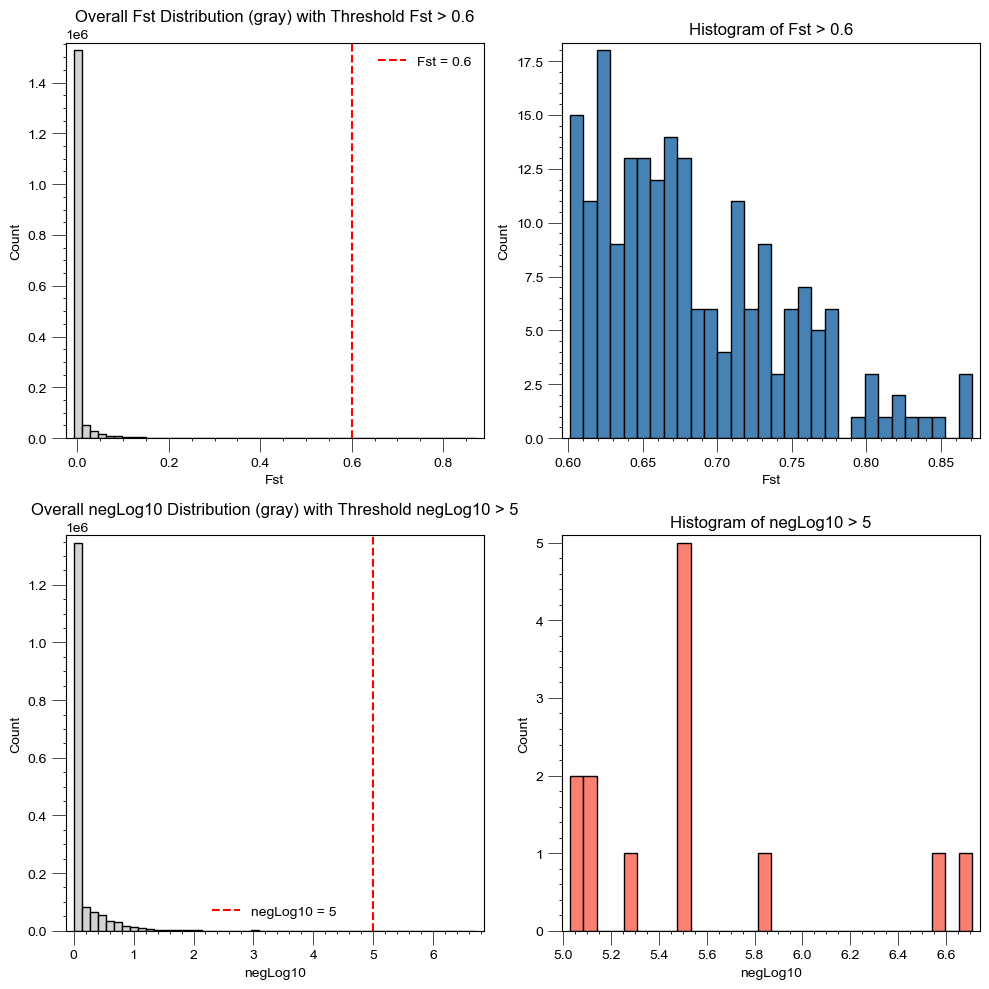

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from aquarel import load_theme

# Load and apply the theme
theme = load_theme('boxy_light')
theme.apply()

df =df_Fst_GWAS

# 2. Define fixed thresholds
fst_threshold = 0.6
neglog10_threshold = 5

# 3. Filter "high-value" samples by those fixed thresholds
df_high_fst = df.loc[df['Fst'] > fst_threshold, 'Fst']
df_high_neg = df.loc[df['negLog10'] > neglog10_threshold, 'negLog10']

# 4. Plot histograms comparing overall distribution vs. high-value subset
plt.rcParams['font.family'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 4.1 Overall Fst histogram (gray), with vertical line at 0.5
ax1 = axes[0, 0]
ax1.hist(df['Fst'].dropna(), bins=50, color='lightgray', edgecolor='black')
ax1.axvline(fst_threshold, color='red', linestyle='--', label=f'Fst = {fst_threshold}')
ax1.set_title(f'Overall Fst Distribution (gray) with Threshold Fst > {fst_threshold}', fontsize=12)
ax1.set_xlabel('Fst', fontsize=10)
ax1.set_ylabel('Count', fontsize=10)
ax1.legend(frameon=False)
ax1.grid(False)

# 4.2 Histogram of Fst > 0.5 (steelblue)
ax2 = axes[0, 1]
ax2.hist(df_high_fst, bins=30, color='steelblue', edgecolor='black')
ax2.set_title(f'Histogram of Fst > {fst_threshold}', fontsize=12)
ax2.set_xlabel('Fst', fontsize=10)
ax2.set_ylabel('Count', fontsize=10)
ax2.grid(False)

# 4.3 Overall negLog10 histogram (gray), with vertical line at 5
ax3 = axes[1, 0]
ax3.hist(df['negLog10'].dropna(), bins=50, color='lightgray', edgecolor='black')
ax3.axvline(neglog10_threshold, color='red', linestyle='--', label=f'negLog10 = {neglog10_threshold}')
ax3.set_title(f'Overall negLog10 Distribution (gray) with Threshold negLog10 > {neglog10_threshold}', fontsize=12)
ax3.set_xlabel('negLog10', fontsize=10)
ax3.set_ylabel('Count', fontsize=10)
ax3.legend(frameon=False)
ax3.grid(False)

# 4.4 Histogram of negLog10 > 5 (salmon)
ax4 = axes[1, 1]
ax4.hist(df_high_neg, bins=30, color='salmon', edgecolor='black')
ax4.set_title(f'Histogram of negLog10 > {neglog10_threshold}', fontsize=12)
ax4.set_xlabel('negLog10', fontsize=10)
ax4.set_ylabel('Count', fontsize=10)
ax4.grid(False)

# Apply final theme transforms (after disabling grids)
theme.apply_transforms()

plt.tight_layout()
plt.savefig(f'../output/{TARGET}/histogram_fixed_thresholds.pdf')
plt.show()


In [17]:
import pandas as pd

# ——— 假设 df_Fst_GWAS 已经读入并命名为 df ———
df = df_Fst_GWAS.copy()

# 1. 阈值设置
neglog10_thr = 5
fst_thr      = 0.6

# 2. 筛选子集
neg_only = df[df['negLog10'] > neglog10_thr]
fst_only = df[df['Fst']      > fst_thr]
both     = df[(df['negLog10'] > neglog10_thr) & (df['Fst'] > fst_thr)]

# 3. 附表 S1：位点数量汇总
counts_df = pd.DataFrame({
    '附表编号 (Table)': ['S1'] * 3,
    '条件 (Condition)': [
        f'negLog10 > {neglog10_thr}',
        f'Fst > {fst_thr}',
        f'negLog10 > {neglog10_thr} 且 Fst > {fst_thr}'
    ],
    '位点数量 (Number_of_sites)': [len(neg_only), len(fst_only), len(both)]
})

# 4. 辅助函数：生成 annotation 分布附表
def make_annotation_table(subset_df, table_id, condition_label):
    tbl = (
        subset_df['annotation']
        .value_counts(dropna=False)
        .rename_axis('注释类型 (Annotation)')
        .reset_index(name='位点数 (Count)')
    )
    tbl.insert(0, '附表编号 (Table)', table_id)
    tbl.insert(1, '条件 (Condition)', condition_label)
    return tbl

# 5. 附表 S2–S4：各子集的 annotation 分布
neg_ann_df  = make_annotation_table(neg_only, 'S2', f'negLog10 > {neglog10_thr}')
fst_ann_df  = make_annotation_table(fst_only, 'S3', f'Fst > {fst_thr}')
both_ann_df = make_annotation_table(both,     'S4', f'negLog10 > {neglog10_thr} 且 Fst > {fst_thr}')

# 6. 导出到单个 Excel，多工作表
with pd.ExcelWriter(f'../output/{TARGET}/Supplementary_Tables.xlsx', engine='xlsxwriter') as writer:
    counts_df.to_excel(writer, sheet_name='Table_S1_Counts', index=False)
    neg_ann_df.to_excel(writer, sheet_name='Table_S2_NegLog10', index=False)
    fst_ann_df.to_excel(writer, sheet_name='Table_S3_Fst',       index=False)
    both_ann_df.to_excel(writer, sheet_name='Table_S4_Both',      index=False)

print("已生成并导出 Supplementary_Tables.xlsx，包含 S1–S4 共四个附表。")


已生成并导出 Supplementary_Tables.xlsx，包含 S1–S4 共四个附表。


/tmp/ipykernel_26674/53338845.py:34: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_26674/53338845.py:34: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_26674/53338845.py:34: UserWarning: Glyph 38408 (\N{CJK UNIFIED IDEOGRAPH-9608}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_26674/53338845.py:34: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_26674/53338845.py:34: UserWarning: Glyph 26465 (\N{CJK UNIFIED IDEOGRAPH-6761}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_26674/53338845.py:34: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_26674/53338845.py:34: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) Arial.
  plt.tight_l

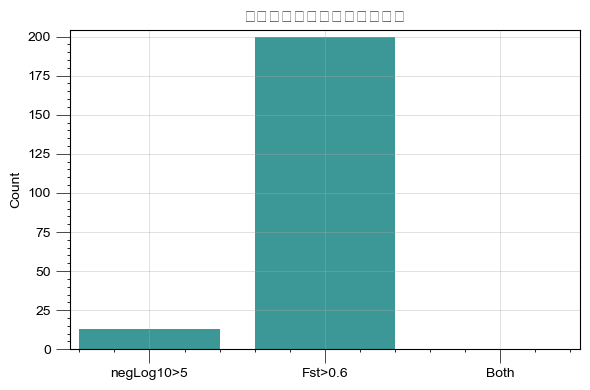

/tmp/ipykernel_26674/53338845.py:55: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_26674/53338845.py:55: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_26674/53338845.py:55: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_26674/53338845.py:55: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/home/luolintao/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/home/luolintao/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font

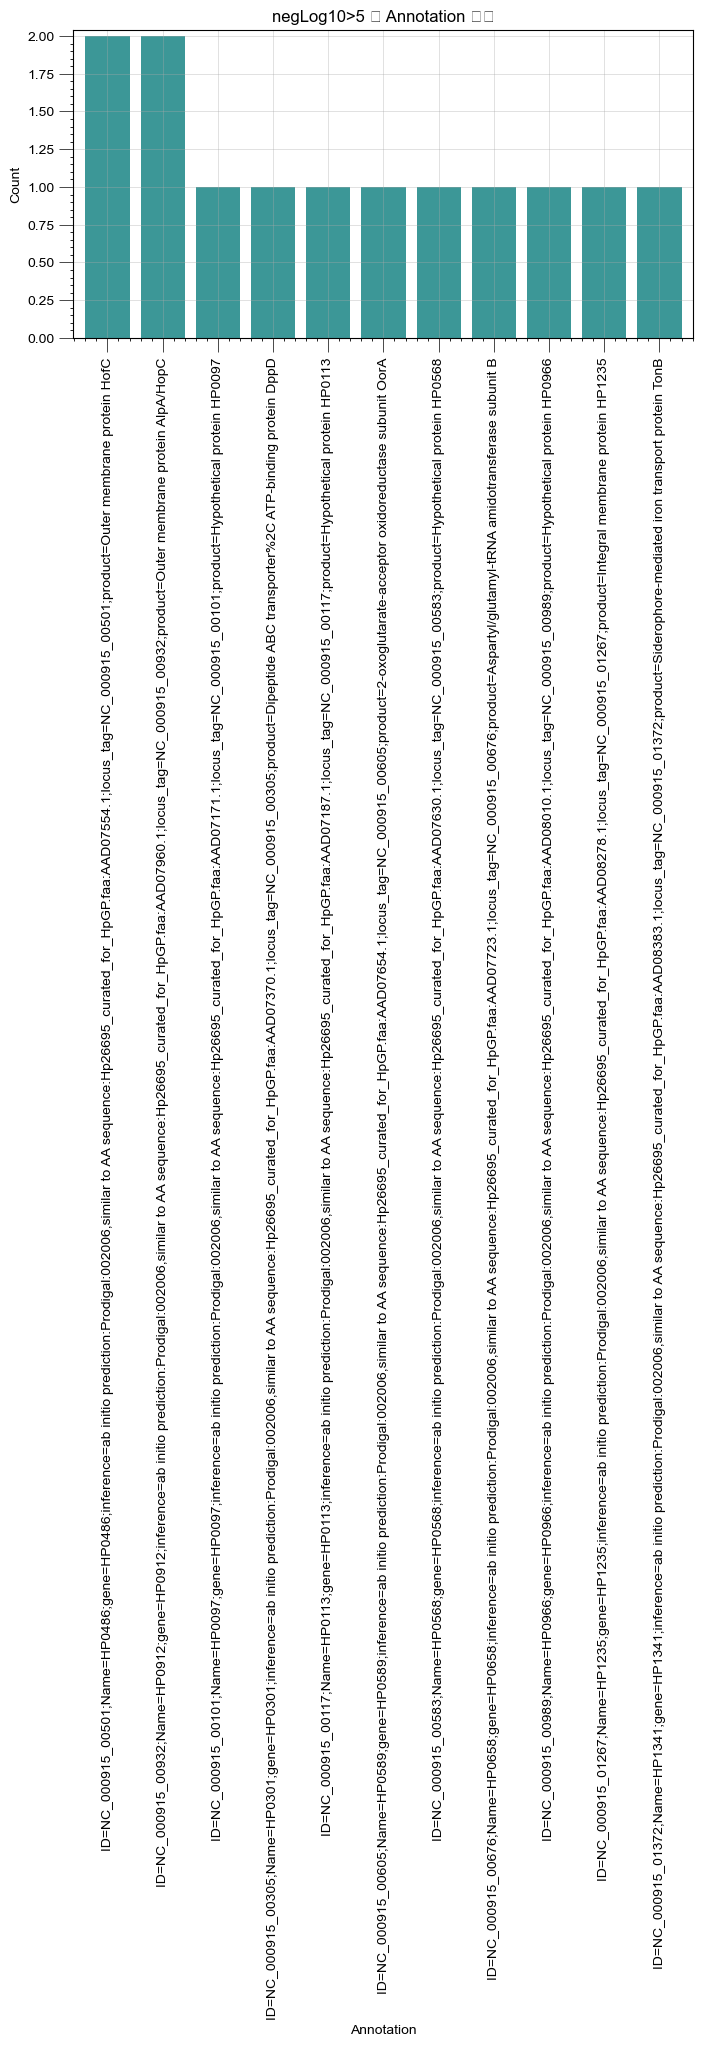

/tmp/ipykernel_26674/53338845.py:55: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_26674/53338845.py:55: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_26674/53338845.py:55: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_26674/53338845.py:55: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/home/luolintao/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/home/luolintao/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font

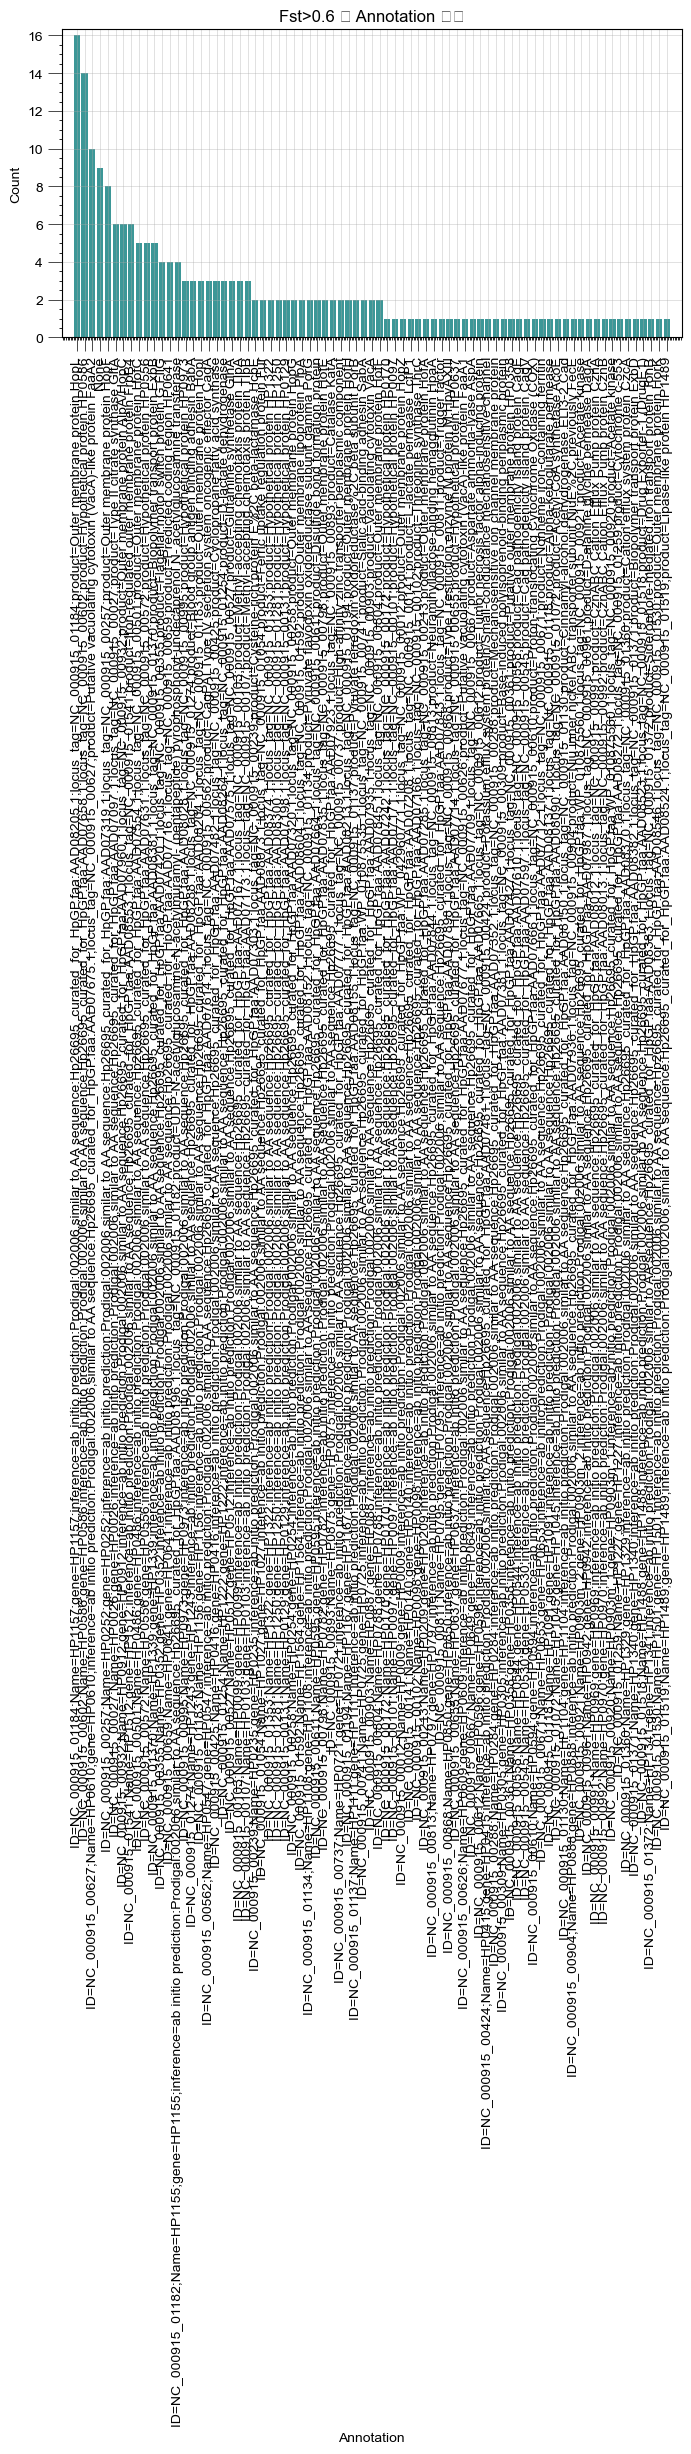

/tmp/ipykernel_26674/53338845.py:55: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_26674/53338845.py:55: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_26674/53338845.py:55: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  plt.tight_layout()
/home/luolintao/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/home/luolintao/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/home/luolintao/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRA

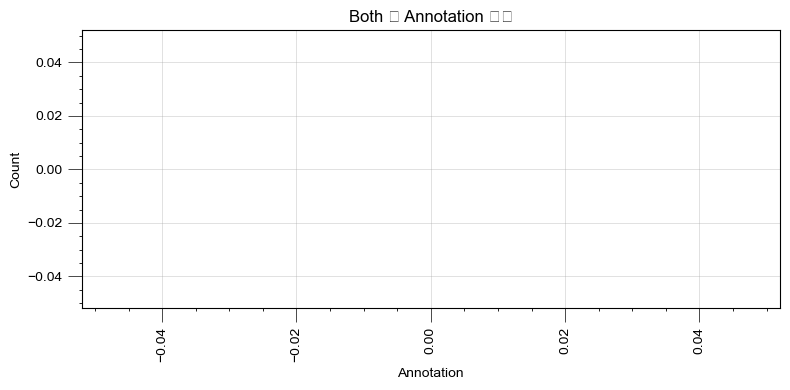

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 假设前面已经算好这三个 DataFrame 子集：
# neg_high: df[df['negLog10'] > neglog10_threshold]
# fst_high: df[df['Fst']      > fst_threshold]
# both:     df[(df['negLog10'] > neglog10_threshold) & (df['Fst'] > fst_threshold)]

# 先重新计算一下以防万一
neglog10_threshold = 5
fst_threshold     = 0.6

df = df_Fst_GWAS.copy()
neg_high = df.loc[df['negLog10'] > neglog10_threshold]
fst_high = df.loc[df['Fst']      > fst_threshold]
both     = df.loc[
    (df['negLog10'] > neglog10_threshold) &
    (df['Fst']      > fst_threshold)
]

# 1. 三类位点数量
count_neg  = len(neg_high)
count_fst  = len(fst_high)
count_both = len(both)

# 绘制位点数量柱状图
plt.figure(figsize=(6,4))
plt.bar(
    ['negLog10>5', f'Fst>{fst_threshold}', 'Both'],
    [count_neg, count_fst, count_both]
)
plt.ylabel('Count')
plt.title('不同阈值条件下位点数量比较')
plt.tight_layout()
plt.savefig('count_comparison.png')
plt.show()

# 2. 计算 annotation 分布
neg_ann  = neg_high['annotation'].value_counts(dropna=False)
fst_ann  = fst_high['annotation'].value_counts(dropna=False)
both_ann = both['annotation'].value_counts(dropna=False)

# 绘制三张 annotation 分布图
for name, ann_counts in [
    (f'negLog10>{neglog10_threshold}', neg_ann),
    (f'Fst>{fst_threshold}',        fst_ann),
    ('Both',                        both_ann)
]:
    plt.figure(figsize=(8,4))
    plt.bar(ann_counts.index.astype(str), ann_counts.values)
    plt.xticks(rotation=90)
    plt.xlabel('Annotation')
    plt.ylabel('Count')
    plt.title(f'{name} 的 Annotation 分布')
    plt.tight_layout()
    # 如果需要保存：
   # plt.savefig(f'annotation_distribution_{name.replace(">", "_")}.png')
    plt.show()
